In [69]:
# =============================
# 1. Imports
# =============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# =============================
# 2. Load Iberia dataset
# =============================
PROJECT_ROOT = Path().resolve().parent
data_path = PROJECT_ROOT / "data" / "processed" / "spain.csv"

df_ib = pd.read_csv(
    data_path,
    parse_dates=["DateUTC"],
    index_col="DateUTC"
).sort_index()

df_ib["hour"] = df_ib.index.hour
df_ib["dayofweek"] = df_ib.index.dayofweek
df_ib["month"] = df_ib.index.month

# ---- define target ----
target_col = "Value"  

features = [target_col, "hour", "dayofweek", "month"]

feature_cols = ["Value", "hour", "dayofweek", "month"]
n_features = len(feature_cols)

In [71]:
# =============================
# 2. Train/Test Split
# =============================
train = df_ib.loc[:"2025-07-31"].copy()
test  = df_ib.loc["2025-08-01":].copy()

In [74]:
# =============================
# 4. Create sequences
# =============================
def create_sequences(data, window_size=24, horizon=24):
    X, y = [], []
    for i in range(len(data) - window_size - horizon):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon, 0])  # target only
    return np.array(X), np.array(y)

window_size = 24
horizon = 24

X_train, y_train = create_sequences(train_scaled, window_size, horizon)
X_test, y_test   = create_sequences(test_scaled, window_size, horizon)

n_features = X_train.shape[2]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (24793, 24, 4)
y_train shape: (24793, 24)


In [75]:
# =============================
# 7. Build LSTM model
# =============================
model = Sequential([
     Input(shape=(window_size, n_features)),
     LSTM(64, return_sequences=True),
     Dropout(0.2),
     LSTM(32),
     Dropout(0.2),
     Dense(horizon)
 ])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [76]:
# =============================
# 8. Train
# =============================
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0292 - val_loss: 0.0070
Epoch 2/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0093 - val_loss: 0.0040
Epoch 3/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0059 - val_loss: 0.0030
Epoch 4/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 5/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 6/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 7/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 8/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 9/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 10/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0020 - val_loss: 0.0017
Epoch 11/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0019 - val_loss: 0.0016
Epoch 12/20
698/698 ━━━━━━━━━━━━━━━━━

In [77]:
# =============================
# 7. Predict
# =============================
y_pred = model.predict(X_test)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [78]:
# =============================
# 8. Inverse scaling (only target)
# =============================
def invert_scale(preds, scaler, n_features):
    temp = np.zeros((preds.shape[0], preds.shape[1], n_features))
    temp[:, :, 0] = preds  # target is first column
    inv = scaler.inverse_transform(temp.reshape(-1, n_features))
    return inv[:, 0].reshape(preds.shape)

# y_pred_inv = invert_scale(y_pred, scaler, n_features)
# y_test_inv = invert_scale(y_test, scaler, n_features)

y_pred_inv = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

print("Pred sample:", y_pred_inv[0][:5])
print("True sample:", y_test_inv[0][:5])

Pred sample: [23551.893 22771.686 22124.086 21759.955 21844.607]
True sample: [23562. 22682. 22185. 21936. 22320.]


In [79]:
# =============================
# 9. Metrics
# =============================
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# ---- Full test metrics (all forecasts, flattened)
y_test_full = y_test_inv.flatten()
y_pred_full = y_pred_inv.flatten()

full_mae = mean_absolute_error(y_test_full, y_pred_full)
full_rmse = np.sqrt(mean_squared_error(y_test_full, y_pred_full))
full_mape = mape(y_test_full, y_pred_full)

print(f"Full Test MAE:  {full_mae:.4f}")
print(f"Full Test RMSE: {full_rmse:.4f}")
print(f"Full Test MAPE: {full_mape:.2f}%")

# ---- 24H metrics (first forecast window only)
y_test_24h = y_test_inv[0]
y_pred_24h = y_pred_inv[0]

mae_24h = mean_absolute_error(y_test_24h, y_pred_24h)
rmse_24h = np.sqrt(mean_squared_error(y_test_24h, y_pred_24h))
mape_24h = mape(y_test_24h, y_pred_24h)

print(f"24H Test MAE:  {mae_24h:.4f}")
print(f"24H Test RMSE: {rmse_24h:.4f}")
print(f"24H Test MAPE: {mape_24h:.2f}%")

Full Test MAE:  774.9657
Full Test RMSE: 1068.7173
Full Test MAPE: 2.84%
24H Test MAE:  667.8318
24H Test RMSE: 942.9251
24H Test MAPE: 2.47%


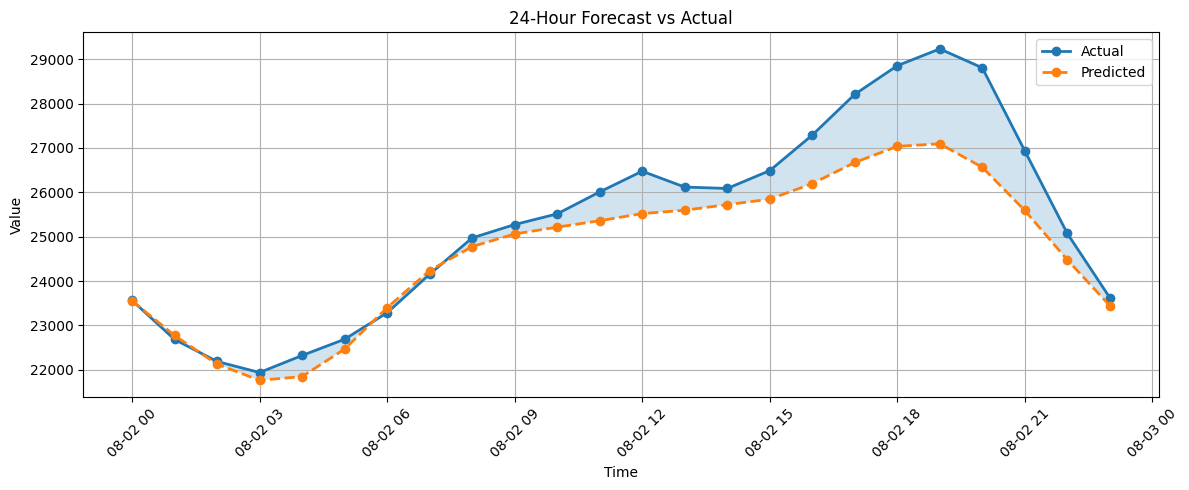

In [83]:
timestamps_24h = test.index[window_size : window_size + horizon]

plt.figure(figsize=(12, 5))

plt.plot(timestamps_24h, y_test_24h, 
         marker="o", linewidth=2, label="Actual")

plt.plot(timestamps_24h, y_pred_24h, 
         marker="o", linestyle="--", linewidth=2, label="Predicted")

plt.fill_between(timestamps_24h, y_test_24h, y_pred_24h, alpha=0.2)

plt.title("24-Hour Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel(target_col)

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()